In [7]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Connect to database
conn = pymysql.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="root123",
    database="sakila",
    connect_timeout=5
)
cursor = conn.cursor()
print("Connected ✅")

Connected ✅


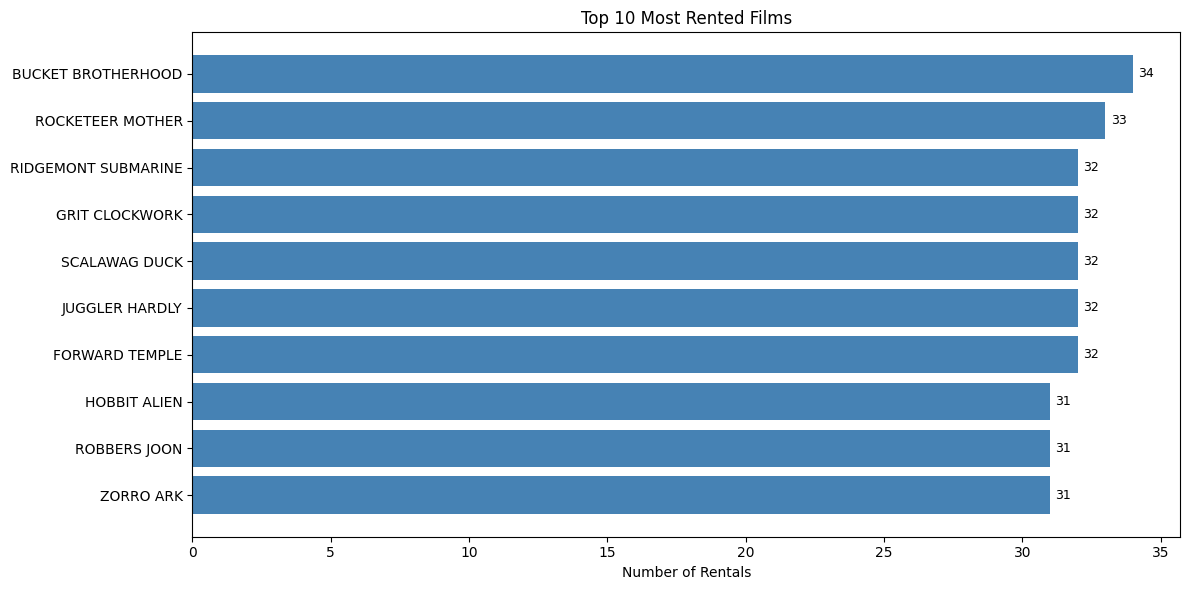

Chart 1 saved ✅


In [8]:
# Chart 1: Top 10 Films by Rentals
cursor.execute("""
    SELECT f.title, COUNT(r.rental_id) as rental_count
    FROM rental r
    JOIN inventory i ON r.inventory_id = i.inventory_id
    JOIN film f ON i.film_id = f.film_id
    GROUP BY f.title
    ORDER BY rental_count DESC
    LIMIT 10
""")
rows = cursor.fetchall()
df_films = pd.DataFrame(rows, columns=['Film', 'Rentals'])

plt.figure(figsize=(12, 6))
bars = plt.barh(df_films['Film'], df_films['Rentals'], color='steelblue')
plt.xlabel('Number of Rentals')
plt.title('Top 10 Most Rented Films')
plt.gca().invert_yaxis()
for bar, val in zip(bars, df_films['Rentals']):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, 
             str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(r'C:\Users\User\OneDrive\Desktop\movie_rental_dw\diagrams\chart1_top_films.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")

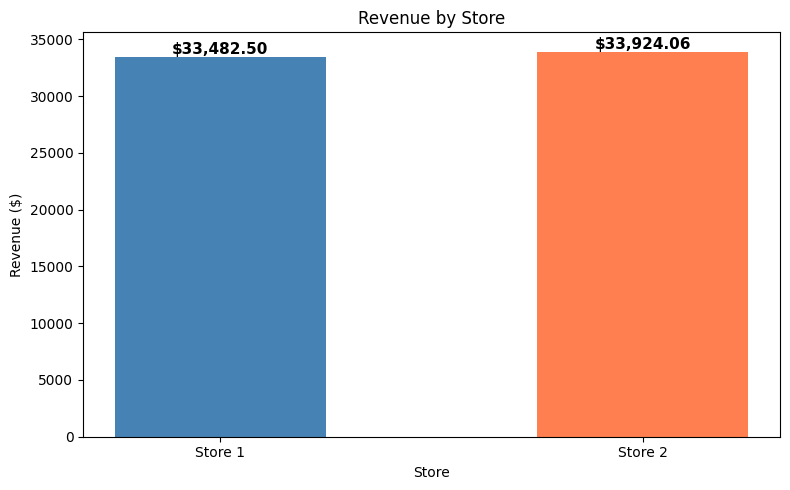

Chart 2 saved ✅


In [9]:
# Chart 2: Revenue by Store
cursor.execute("""
    SELECT s.store_id, SUM(p.amount) as revenue
    FROM payment p
    JOIN staff st ON p.staff_id = st.staff_id
    JOIN store s ON st.store_id = s.store_id
    GROUP BY s.store_id
""")
rows = cursor.fetchall()
df_store = pd.DataFrame(rows, columns=['Store', 'Revenue'])
df_store['Store'] = 'Store ' + df_store['Store'].astype(str)

plt.figure(figsize=(8, 5))
bars = plt.bar(df_store['Store'], df_store['Revenue'], 
               color=['steelblue', 'coral'], width=0.5)
plt.xlabel('Store')
plt.ylabel('Revenue ($)')
plt.title('Revenue by Store')
for bar, val in zip(bars, df_store['Revenue']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${val:,.2f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\OneDrive\Desktop\movie_rental_dw\diagrams\chart2_revenue_store.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✅")

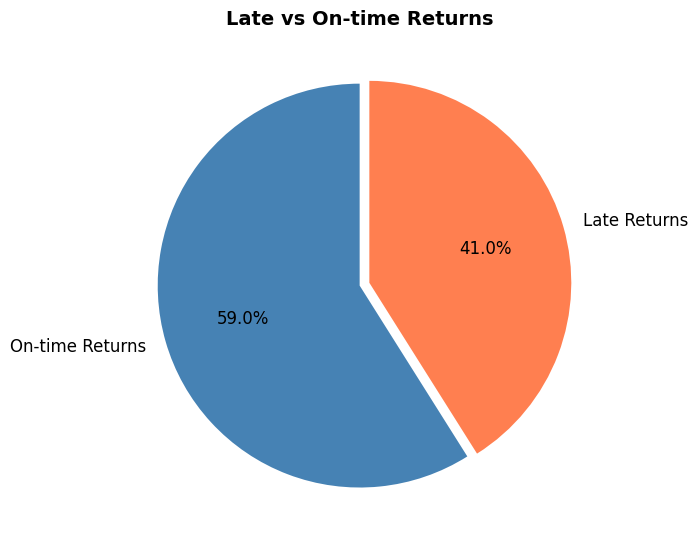

Chart 3 saved ✅


In [10]:
# Chart 3: Late vs On-time Returns
late = 6586
ontime = 16044 - 6586

plt.figure(figsize=(7, 7))
labels = ['On-time Returns', 'Late Returns']
sizes = [ontime, late]
colors = ['steelblue', 'coral']
explode = (0, 0.05)

plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12})
plt.title('Late vs On-time Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\OneDrive\Desktop\movie_rental_dw\diagrams\chart3_late_returns.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✅")